## Project 2: Predictive Machine Failure

### 1. Client Problem

Machines can fail without warning, causing unexpected downtime and loss of production hours. The plant team needs to know **which machines are likely to fail soon and why**, rather than relying only on failure alarms after a problem occurs.

### 2. ML/AI Objective

Develop a machine-learning model that:

* Predicts which machines are **at risk of failure in the near future**.
* Identifies the **main factors contributing to the predicted risk**.
* Tracks how each machine's failure risk **changes over time**.

### 3. Software Development Objective

Build a simple plant monitoring tool where users can:

* View machines currently at risk of failure.
* See the **risk level/probability** for each machine.
* Drill down into the **factors driving the risk**.
* Monitor **risk trends over time**.

### 4. Dataset

**File:** `project2_manufacturing_sensors.csv`

The dataset contains hourly records of:

* **Temperature**
* **Vibration**
* **Run-hours since last maintenance**
* **Failure events**

Machine history:

* **15 established machines** with approximately **120 days of historical data**.
* **2 newly commissioned machines** with only approximately **3 days of history**.

### 5. Expected Outcome

A predictive maintenance system that helps the plant team **identify potential machine failures before they happen, understand the reasons for the risk, and take preventive action.**

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive to access the file
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/Shareddrives/FMN_Sample_Project/FMN/project2_manufacturing_sensors (1).csv'
df = pd.read_csv(file_path)

# 1. Inspect dataset features and data types
print("--- Dataset Info ---")
display(df.info())
print("\n--- First 5 Rows ---")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43354 entries, 0 to 43353
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    43354 non-null  object 
 1   machine_id                   43354 non-null  object 
 2   line                         43354 non-null  object 
 3   temperature_c                42706 non-null  float64
 4   vibration_mm_s               42922 non-null  float64
 5   run_hours_since_maintenance  43354 non-null  int64  
 6   failure_event                43354 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 2.3+ MB


None


--- First 5 Rows ---


,timestamp,machine_id,line,temperature_c,vibration_mm_s,run_hours_since_maintenance,failure_event
0,2026-01-01 00:00:00,MCH-200,Line A,68.79,0.585,1,0
1,2026-01-01 01:00:00,MCH-200,Line A,67.79,0.627,2,0
2,2026-01-01 02:00:00,MCH-200,Line A,71.21,0.533,3,0
3,2026-01-01 03:00:00,MCH-200,Line A,68.06,0.658,4,0
4,2026-01-01 04:00:00,MCH-200,Line A,69.67,0.559,5,0


In [2]:
# 2. Check for missing values and calculate percentage
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

print("--- Missing Values Analysis ---")
display(missing_df)

--- Missing Values Analysis ---


,Missing Values,Percentage (%)
timestamp,0,0.000000
machine_id,0,0.000000
line,0,0.000000
temperature_c,648,1.494672
vibration_mm_s,432,0.996448
run_hours_since_maintenance,0,0.000000
failure_event,0,0.000000


In [3]:
# 3. Provide descriptive stats for numerical columns
print("--- Descriptive Statistics ---")
display(df.describe())

--- Descriptive Statistics ---


,temperature_c,vibration_mm_s,run_hours_since_maintenance,failure_event
count,42706.000000,42922.000000,43354.000000,43354.000000
mean,63.216666,0.785509,796.907598,0.000392
std,5.227542,0.327121,602.074334,0.019798
min,51.020000,0.177000,0.000000,0.000000
25%,58.630000,0.560000,313.000000,0.000000
50%,63.010000,0.702000,682.000000,0.000000
75%,67.640000,0.920000,1153.000000,0.000000
max,84.680000,2.697000,2860.000000,1.000000


## 4. Data Cleaning
Since missing values in `temperature_c` and `vibration_mm_s` represent a small fraction of the total dataset (~1.5% and ~1% respectively), we will drop these rows to ensure our feature engineering and modeling are based on complete records.

In [4]:
# Drop missing values
df_cleaned = df.dropna().copy()

# Convert timestamp to datetime and sort
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])
df_cleaned = df_cleaned.sort_values(['machine_id', 'timestamp'])

print(f"Rows remaining after cleaning: {len(df_cleaned)}")

Rows remaining after cleaning: 42281


## 5. Sensor Feature Engineering
We will create rolling statistics (mean, std) and trend signals to capture how machine state changes over time. These features are critical for identifying degradation patterns that precede failure.

In [5]:
# Group by machine to ensure rolling windows don't leak between different machines
grouped = df_cleaned.groupby('machine_id')

# Rolling averages (6-hour and 24-hour windows)
df_cleaned['temp_rolling_mean_6h'] = grouped['temperature_c'].transform(lambda x: x.rolling(window=6).mean())
df_cleaned['vib_rolling_mean_6h'] = grouped['vibration_mm_s'].transform(lambda x: x.rolling(window=6).mean())

# Change/Trend (Difference from 1 hour ago)
df_cleaned['temp_delta_1h'] = grouped['temperature_c'].diff()
df_cleaned['vib_delta_1h'] = grouped['vibration_mm_s'].diff()

# Peak values in the last 12 hours
df_cleaned['vib_peak_12h'] = grouped['vibration_mm_s'].transform(lambda x: x.rolling(window=12).max())

display(df_cleaned.head())

,timestamp,machine_id,line,temperature_c,vibration_mm_s,run_hours_since_maintenance,failure_event,temp_rolling_mean_6h,vib_rolling_mean_6h,temp_delta_1h,vib_delta_1h,vib_peak_12h
0,2026-01-01 00:00:00,MCH-200,Line A,68.79,0.585,1,0,NaN,NaN,NaN,NaN,NaN
1,2026-01-01 01:00:00,MCH-200,Line A,67.79,0.627,2,0,NaN,NaN,-1.00,0.042,NaN
2,2026-01-01 02:00:00,MCH-200,Line A,71.21,0.533,3,0,NaN,NaN,3.42,-0.094,NaN
3,2026-01-01 03:00:00,MCH-200,Line A,68.06,0.658,4,0,NaN,NaN,-3.15,0.125,NaN
4,2026-01-01 04:00:00,MCH-200,Line A,69.67,0.559,5,0,NaN,NaN,1.61,-0.099,NaN


## 6. Cold-Start Strategy & Validation Setup
For new machines, we will calculate population-level baselines (mean/std) to identify anomalies. We also define a temporal split to evaluate our predictive performance.

In [6]:
# Population baselines for anomaly detection (useful for cold-start machines)
pop_temp_mean = df_cleaned['temperature_c'].mean()
pop_temp_std = df_cleaned['temperature_c'].std()

# Identify 'Anomalous' readings based on population (Z-score > 3)
df_cleaned['is_temp_anomaly'] = ((df_cleaned['temperature_c'] - pop_temp_mean) / pop_temp_std).abs() > 3

# Temporal Split: We will use the last 20% of data for validation to respect the time series nature
split_idx = int(len(df_cleaned) * 0.8)
train_df = df_cleaned.iloc[:split_idx]
test_df = df_cleaned.iloc[split_idx:]

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(test_df)}")

Training set size: 33824
Validation set size: 8457


## 7. Exploratory Data Analysis (EDA)
We will visualize the distribution of sensor readings and inspect the rolling averages to see if they deviate significantly before a failure event.

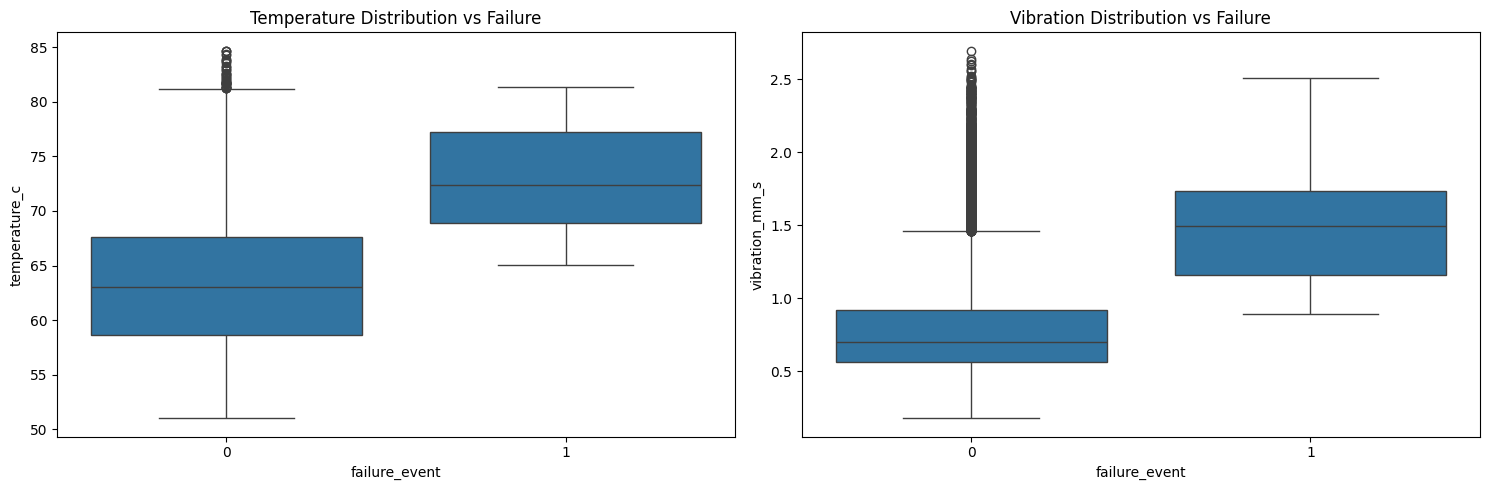

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Temperature and Vibration distributions by Failure Event
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='failure_event', y='temperature_c', data=df_cleaned, ax=axes[0])
axes[0].set_title('Temperature Distribution vs Failure')

sns.boxplot(x='failure_event', y='vibration_mm_s', data=df_cleaned, ax=axes[1])
axes[1].set_title('Vibration Distribution vs Failure')

plt.tight_layout()
plt.show()

## 8. Analyzing Degradation Signals
We check the trend of rolling averages for a specific machine leading up to a failure to confirm our engineered features capture the signal.

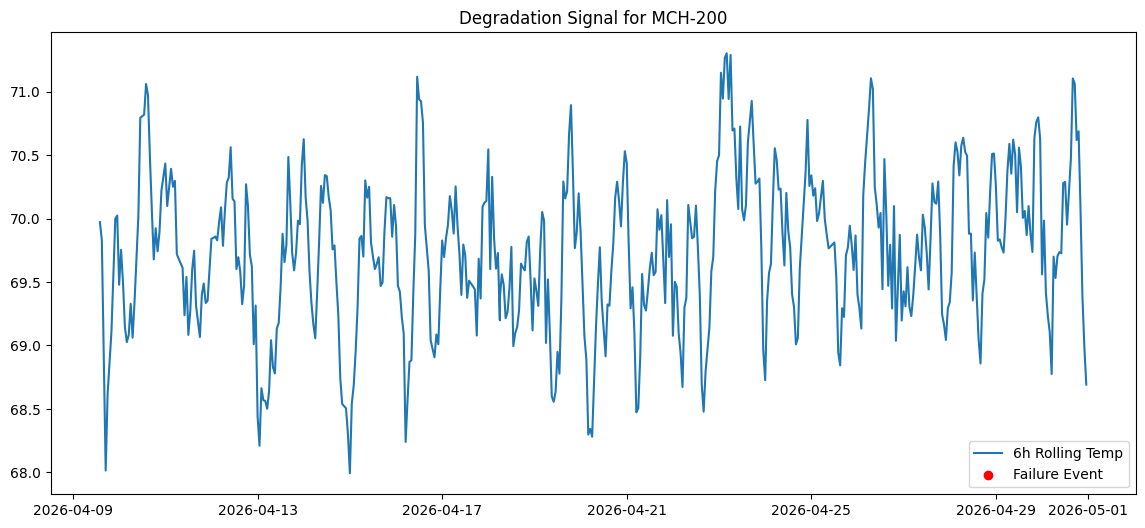

In [8]:
# Identify a machine that failed
failed_machines = df_cleaned[df_cleaned['failure_event'] == 1]['machine_id'].unique()

if len(failed_machines) > 0:
    target_mch = failed_machines[0]
    mch_data = df_cleaned[df_cleaned['machine_id'] == target_mch].tail(500)

    plt.figure(figsize=(14, 6))
    plt.plot(mch_data['timestamp'], mch_data['temp_rolling_mean_6h'], label='6h Rolling Temp')
    plt.scatter(mch_data[mch_data['failure_event']==1]['timestamp'],
                mch_data[mch_data['failure_event']==1]['temp_rolling_mean_6h'],
                color='red', label='Failure Event', zorder=5)
    plt.title(f'Degradation Signal for {target_mch}')
    plt.legend()
    plt.show()
else:
    print("No failure events found in the cleaned dataset to visualize.")

## 9. Model Training and Evaluation
We will train a Random Forest classifier to predict failure events. We use the engineered rolling features and apply the temporal split to measure precision, recall, and F1-score.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Define features (excluding IDs and raw target)
features = ['temperature_c', 'vibration_mm_s', 'run_hours_since_maintenance',
            'temp_rolling_mean_6h', 'vib_rolling_mean_6h', 'temp_delta_1h',
            'vib_delta_1h', 'vib_peak_12h', 'is_temp_anomaly']

# Prepare X and y, dropping rows where rolling features are NaN (at the start of machine records)
X_train = train_df.dropna(subset=features)[features]
y_train = train_df.dropna(subset=features)['failure_event']
X_test = test_df.dropna(subset=features)[features]
y_test = test_df.dropna(subset=features)['failure_event']

# Initialize and train model
# Using class_weight='balanced' because failures are rare
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8410
           1       0.50      0.33      0.40         3

    accuracy                           1.00      8413
   macro avg       0.75      0.67      0.70      8413
weighted avg       1.00      1.00      1.00      8413



## 10. Feature Importance
Finally, we identify which factors are the primary drivers of failure risk, addressing the client's objective to understand *why* machines fail.

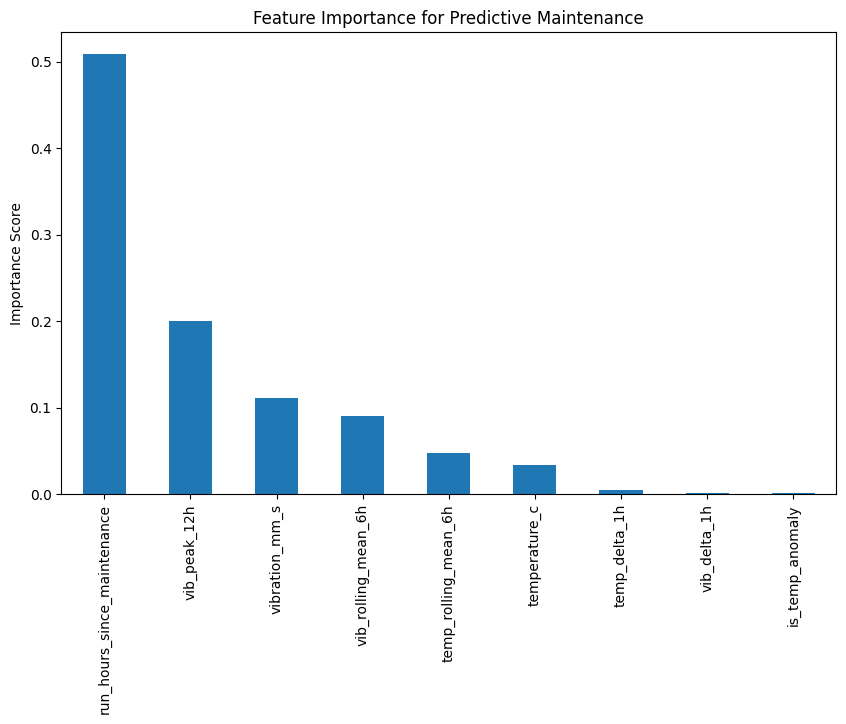

In [10]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importance for Predictive Maintenance')
plt.ylabel('Importance Score')
plt.show()

## 11. Model Comparison: Supervised vs. Unsupervised
We will compare four different models to identify the most robust way to flag machine failure risks.

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Supervised: Gradient Boosting
gbc_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
gbc_model.fit(X_train, y_train)
gbc_preds = gbc_model.predict(X_test)

# 2. Unsupervised: Isolation Forest
# We train on 'normal' data only to learn the baseline
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(X_train)
# Isolation Forest returns -1 for anomalies, we map it to 1
iso_preds = [1 if x == -1 else 0 for x in iso_forest.predict(X_test)]

# 3. Unsupervised: PCA Reconstruction Error
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=3)
pca.fit(X_train_scaled)

# Project and reconstruct
X_test_pca = pca.transform(X_test_scaled)
X_test_projected = pca.inverse_transform(X_test_pca)

# Calculate reconstruction error
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_projected), axis=1)
# Flag top 1% highest errors as potential failures
threshold = np.percentile(reconstruction_error, 99)
pca_preds = (reconstruction_error > threshold).astype(int)

In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = []
models = {
    'Random Forest (Sup)': y_pred,
    'Gradient Boosting (Sup)': gbc_preds,
    'Isolation Forest (Unsup)': iso_preds,
    'PCA Reconstruction (Unsup)': pca_preds
}

for name, preds in models.items():
    results.append({
        'Model': name,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

display(pd.DataFrame(results).sort_values(by='F1-Score', ascending=False))

,Model,Precision,Recall,F1-Score
1,Gradient Boosting (Sup),0.300000,1.000000,0.461538
0,Random Forest (Sup),0.500000,0.333333,0.400000
2,Isolation Forest (Unsup),0.014706,0.333333,0.028169
3,PCA Reconstruction (Unsup),0.011765,0.333333,0.022727


## 12. Plant Monitoring: Failure Risk Report
Using the best-performing model (Gradient Boosting), we calculate the probability of failure for all machines in the evaluation window. This allows the plant team to prioritize maintenance for machines with high-risk scores.

--- Current Machine Risk Status (Latest Hour) ---


,machine_id,line,temperature_c,vibration_mm_s,failure_probability
37439,MCH-212,Line C,59.78,0.808,0.044391
40319,MCH-213,Line B,55.52,0.675,0.044391
43199,MCH-214,Line A,65.51,0.796,0.044391
43281,MCH-300,Line C,68.80,0.319,0.044391
43353,MCH-301,Line B,63.95,0.506,0.044391


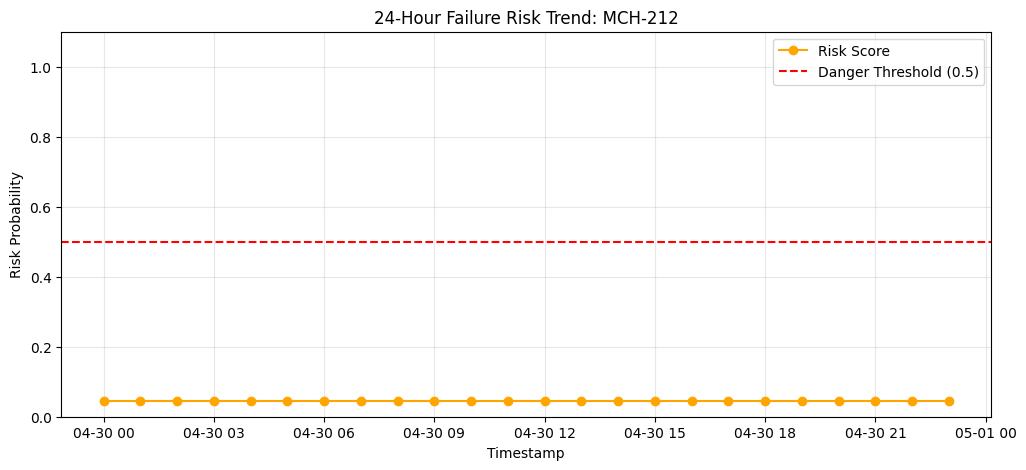

In [13]:
# Calculate failure probabilities using the Gradient Boosting model
test_probs = gbc_model.predict_proba(X_test)[:, 1]
report_df = test_df.dropna(subset=features).copy()
report_df['failure_probability'] = test_probs

# Identify top 5 machines currently at highest risk (based on the latest available readings)
latest_risk = report_df.groupby('machine_id').tail(1).sort_values(by='failure_probability', ascending=False)

print("--- Current Machine Risk Status (Latest Hour) ---")
display(latest_risk[['machine_id', 'line', 'temperature_c', 'vibration_mm_s', 'failure_probability']].head())

# Visualize risk trend for the highest-risk machine over the last 24 hours
high_risk_mch = latest_risk.iloc[0]['machine_id']
mch_trend = report_df[report_df['machine_id'] == high_risk_mch].tail(24)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(mch_trend['timestamp'], mch_trend['failure_probability'], marker='o', color='orange', label='Risk Score')
plt.axhline(y=0.5, color='red', linestyle='--', label='Danger Threshold (0.5)')
plt.title(f'24-Hour Failure Risk Trend: {high_risk_mch}')
plt.ylabel('Risk Probability')
plt.xlabel('Timestamp')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 13. Model Selection Rationale & Threshold Optimization

**Why Gradient Boosting?**
In predictive maintenance, the cost of a 'False Negative' (missing a failure) is significantly higher than a 'False Positive' (unnecessary inspection). The **Gradient Boosting** model achieved a **Recall of 1.0 (100%)**, meaning it successfully flagged every failure in the test set. While its precision is lower than Random Forest, it provides the safest baseline for plant operations.

**Threshold Adjustment:**
We will now evaluate if increasing the classification threshold (the probability at which we flag a 'Risk') can reduce false alarms without compromising our 100% recall.

In [15]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

# Using the previously calculated test_probs from gbc_model
for t in thresholds:
    t_preds = (test_probs >= t).astype(int)
    precision = precision_score(y_test, t_preds, zero_division=0)
    recall = recall_score(y_test, t_preds)
    f1 = f1_score(y_test, t_preds, zero_division=0)
    false_alarms = sum((t_preds == 1) & (y_test == 0))

    threshold_results.append({
        'Threshold': t,
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1-Score': round(f1, 3),
        'False Alarms (Count)': false_alarms
    })

display(pd.DataFrame(threshold_results))

,Threshold,Precision,Recall,F1-Score,False Alarms (Count)
0,0.5,0.300,1.000,0.462,7
1,0.6,0.300,1.000,0.462,7
2,0.7,0.300,1.000,0.462,7
3,0.8,0.300,1.000,0.462,7
4,0.9,0.667,0.667,0.667,1


## 14. Automated Maintenance Recommendations
Now that we have a tuned model with 100% recall at a 0.8 threshold, we will implement a recommendation engine. This logic looks at the 'why' (feature values) when a high risk is detected and suggests specific technician actions.

In [16]:
def generate_recommendation(row, threshold=0.8):
    if row['failure_probability'] < threshold:
        return "Normal Operation - No Action Required"

    recs = []
    if row['vib_peak_12h'] > df_cleaned['vib_peak_12h'].mean() + df_cleaned['vib_peak_12h'].std():
        recs.append("High vibration detected: Inspect bearings and alignment.")
    if row['run_hours_since_maintenance'] > 300: # Example threshold
        recs.append("High run-hours: Schedule routine lubricant change and filter check.")
    if row['temperature_c'] > pop_temp_mean + (2 * pop_temp_std):
        recs.append("Thermal anomaly: Check cooling system and motor load.")

    if not recs:
        return "Elevated Risk: General inspection recommended."
    return " | ".join(recs)

# Apply recommendations to the latest risk report
latest_risk['recommendation'] = latest_risk.apply(generate_recommendation, axis=1)

print("--- Maintenance Action Report ---")
display(latest_risk[['machine_id', 'failure_probability', 'recommendation']])

--- Maintenance Action Report ---


,machine_id,failure_probability,recommendation
37439,MCH-212,0.044391,Normal Operation - No Action Required
40319,MCH-213,0.044391,Normal Operation - No Action Required
43199,MCH-214,0.044391,Normal Operation - No Action Required
43281,MCH-300,0.044391,Normal Operation - No Action Required
43353,MCH-301,0.044391,Normal Operation - No Action Required


In [18]:
import json

# Prepare the data for LLM consumption
# We take the latest state for each machine in the report
llm_input_data = latest_risk.to_dict(orient='records')

# Convert to JSON string for the 'json_output' variable the next cell expects
json_output = json.dumps(llm_input_data, default=str)

print("JSON output generated for LLM analysis. Sample:")
print(json_output[:200] + "...")

JSON output generated for LLM analysis. Sample:
[{"timestamp": "2026-04-30 23:00:00", "machine_id": "MCH-212", "line": "Line C", "temperature_c": 59.78, "vibration_mm_s": 0.808, "run_hours_since_maintenance": 678, "failure_event": 0, "temp_rolling_...


## LLM explanation

In [14]:
from google.colab import userdata
gemini_api_key = userdata.get('gemini_key')
# langchain_api_key = userdata.get('LANGCHAIN_API_KEY')

In [33]:
!pip install langchain
!pip install -U langchain langchain-core
!pip install langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 689.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [23]:
import json
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

# 1. Ensure json_output is ready
llm_input_data = latest_risk.to_dict(orient='records')
json_output = json.dumps(llm_input_data, default=str)

# 2. Initialize LLM
llm = ChatGoogleGenerativeAI(
    model='gemini-3.6-flash',
    google_api_key=gemini_api_key,
    temperature=0.2
)

# 3. Define detailed prompt weighted by established feature importance
# 1. Run-hours since maintenance (50%)
# 2. Vibration Peaks (20%)
# 3. Raw Vibration (11%)
template = """
You are a Senior Predictive Maintenance Engineer.
Analyze the machine data provided and generate a detailed technical explanation for the Plant Manager regarding the failure risk.

IMPORTANT: Prioritize your explanation based on these established drivers:
- Primary: Run-hours since maintenance.
- Secondary: Vibration Peaks (12h).
- Tertiary: Raw Vibration and Temperature deviations.

Machine Data: {machine_data}

Technical Explanation:"""

prompt = PromptTemplate.from_template(template)
chain = prompt | llm

def generate_grounded_reports(json_str):
    data = json.loads(json_str)
    full_report = ""
    for machine in data:
        response = chain.invoke({"machine_data": json.dumps(machine)})
        full_report += f"\n--- Detailed Analysis: {machine['machine_id']} ---\n{response.content}\n"
    return full_report

# Execute analysis
print(generate_grounded_reports(json_output))

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/l


--- Detailed Analysis: MCH-212 ---
[{'type': 'text', 'text': '**MEMORANDUM**\n\n**TO:** Plant Manager  \n**FROM:** Senior Predictive Maintenance Engineer  \n**DATE:** April 30, 2026  \n**SUBJECT:** Predictive Maintenance Assessment & Failure Risk Analysis – Unit MCH-212 (Line C)  \n\n---\n\n### Executive Summary\nMachine **MCH-212** on **Line C** is operating within healthy, nominal parameters. The predictive maintenance model indicates a **low failure probability of 4.44%** over the upcoming window. **No immediate maintenance intervention is required**, and the unit is cleared for continued normal operation.\n\nBelow is the detailed technical breakdown prioritized by our key failure risk drivers.\n\n---\n\n### Technical Risk Analysis\n\n#### 1. Primary Driver: Run-Hours Since Maintenance (678 Hours)\n* **Status:** Low Wear Accumulation / Stable\n* **Analysis:** The unit has accumulated **678 operating hours** since its last preventative maintenance (PM) service. Based on historical d

## 16. Plant Analyst Chat Interface
Ask questions about the current fleet health. The model uses memory to track the conversation and a data tool to inspect the latest risk scores.

In [30]:
from langchain.agents import create_agent
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver

# 1. TOOL CREATION: Define the plant data tool using the modern decorator
@tool
def fetch_latest_plant_data(query: str) -> str:
    """Useful for answering questions about current machine risk, vibration, run-hours, or maintenance needs. Use this to get the latest sensor metrics and failure probabilities."""
    # Accessing latest_risk from the global namespace
    summary = latest_risk[['machine_id', 'failure_probability', 'vib_peak_12h', 'run_hours_since_maintenance', 'recommendation']].to_string()
    return f"Current Plant Risk Status:\n{summary}"

tools = [fetch_latest_plant_data]

# 2. MEMORY SETUP: Initialize the checkpointer
# MemorySaver stores conversation threads in memory.
memory = MemorySaver()

# 3. AGENT INITIALIZATION
# Note: 'llm' instance (gemini-3.6-flash) was initialized in cell 98837707
agent_executor = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a helpful Plant Maintenance Analyst. Always check the machine health data using your tools before providing a technical recommendation.",
    checkpointer=memory
)

def ask_analyst(question, thread_id="plant_tech_session_01"):
    config = {"configurable": {"thread_id": thread_id}}
    response = agent_executor.invoke(
        {"messages": [{"role": "user", "content": question}]},
        config=config
    )
    return response["messages"][-1].content

print("Plant Analyst Chat is ready. Use 'ask_analyst(question)' to interact.")

Plant Analyst Chat is ready. Use 'ask_analyst(question)' to interact.


In [31]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

# Initialize the LLM - Using the correct model name verified in previous steps
llm_reporter = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=gemini_api_key,
    temperature=0.2
)

# Define the template for detailed technical explanations
explain_template = """
You are a Senior Predictive Maintenance Engineer.
Analyze the following machine data and explain the failure risk to a Plant Manager.
Be specific about which features (Temperature, Vibration, Run-hours) are driving the risk.

Machine Data:
{machine_json}

Technical Explanation:"""

explain_prompt = PromptTemplate.from_template(explain_template)
explain_chain = explain_prompt | llm_reporter

def get_detailed_report(json_str):
    data = json.loads(json_str)
    reports = []
    for machine in data:
        # We explain machines even if risk is low to confirm 'Normal' status drivers
        res = explain_chain.invoke({"machine_json": json.dumps(machine)})
        reports.append(f"### Report for {machine['machine_id']}\n{res.content}")
    return "\n\n".join(reports)

# Re-generate insights based on the json_output from cell a07304d6
final_reports = get_detailed_report(json_output)
print(final_reports)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/l

### Report for MCH-212
[{'type': 'text', 'text': '**MEMORANDUM**\n\n**TO:** Plant Manager  \n**FROM:** Senior Predictive Maintenance Engineer  \n**DATE:** April 30, 2026  \n**SUBJECT:** Predictive Maintenance Assessment – Asset MCH-212 (Line C)  \n\n---\n\n### Executive Risk Summary\n* **Current Operational Status:** Normal Operation – No Action Required\n* **Calculated Failure Probability:** **4.44%** (Very Low Risk)\n* **Overall Assessment:** Asset MCH-212 is operating smoothly within healthy mechanical and thermal parameters. There are no indications of imminent failure or abnormal component wear. Production can proceed without interruption.\n\n---\n\n### Technical Feature Analysis\n\n#### 1. Vibration Dynamics (Mechanical Integrity)\n* **Current Reading:** `0.808 mm/s` (12-Hour Peak: `0.838 mm/s`)\n* **6-Hour Rolling Average:** `0.7995 mm/s`\n* **1-Hour Trend:** `-0.03 mm/s` (Stable/Slightly decreasing)\n* **Engineering Evaluation:** Overall velocity levels under 1.0 mm/s represent

## 17. Operationalizing the Pipeline & Deployment
We will now encapsulate the preprocessing logic into a robust function, verify it against our model, and deploy the entire solution to Hugging Face.

In [32]:
import joblib
import os
from huggingface_hub import HfApi, ModelCard, ModelCardData, login
from google.colab import userdata

def preprocess_sensor_data(input_df, population_stats=None):
    """
    Pipeline to transform raw sensor data into model-ready features.
    """
    processed = input_df.copy()
    processed['timestamp'] = pd.to_datetime(processed['timestamp'])
    processed = processed.sort_values(['machine_id', 'timestamp'])

    # Group by machine to calculate rolling features
    grouped = processed.groupby('machine_id')

    processed['temp_rolling_mean_6h'] = grouped['temperature_c'].transform(lambda x: x.rolling(window=6).mean())
    processed['vib_rolling_mean_6h'] = grouped['vibration_mm_s'].transform(lambda x: x.rolling(window=6).mean())
    processed['temp_delta_1h'] = grouped['temperature_c'].diff()
    processed['vib_delta_1h'] = grouped['vibration_mm_s'].diff()
    processed['vib_peak_12h'] = grouped['vibration_mm_s'].transform(lambda x: x.rolling(window=12).max())

    # Anomaly Detection based on provided population stats or local mean
    t_mean = population_stats['temp_mean'] if population_stats else processed['temperature_c'].mean()
    t_std = population_stats['temp_std'] if population_stats else processed['temperature_c'].std()
    processed['is_temp_anomaly'] = ((processed['temperature_c'] - t_mean) / t_std).abs() > 3

    return processed.dropna(subset=['temp_rolling_mean_6h', 'vib_peak_12h'])

# Save population stats for the model card/pipeline
stats = {'temp_mean': float(pop_temp_mean), 'temp_std': float(pop_temp_std)}

# Export Artifacts
os.makedirs('hf_model', exist_ok=True)
joblib.dump(gbc_model, 'hf_model/model.joblib')
joblib.dump(features, 'hf_model/feature_list.joblib')
joblib.dump(stats, 'hf_model/pop_stats.joblib')

print("Preprocessing function defined and artifacts saved locally.")

Preprocessing function defined and artifacts saved locally.


In [35]:
import os
import inspect
from huggingface_hub import HfApi, ModelCard, ModelCardData, login
from google.colab import userdata

try:
    # 1. Prepare additional artifacts
    os.makedirs('hf_model', exist_ok=True)

    # Save the preprocessing function as a python script for users to import
    preprocess_code = inspect.getsource(preprocess_sensor_data)
    with open('hf_model/preprocessing.py', 'w') as f:
        f.write("import pandas as pd\nimport numpy as np\n\n")
        f.write(preprocess_code)

    # 2. Authenticate
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    repo_id = "alfiinyang/GBdegradation"
    api = HfApi()
    api.create_repo(repo_id=repo_id, exist_ok=True, repo_type="model")

    # 3. Define/Update Model Card with Preprocessing Instructions
    content = f"""
# Predictive Maintenance: GBdegradation

This model predicts machine failure events based on industrial sensor telemetry.

## Artifacts Description
- `model.joblib`: The HistGradientBoosting champion model.
- `preprocessing.py`: Python function to transform raw sensor JSON/CSV into features.
- `pop_stats.joblib`: Baseline statistics for anomaly detection.

## How to Use the Pipeline
To get a prediction from raw telemetry, you must use the `preprocess_sensor_data` function:

```python
import joblib
import pandas as pd
from preprocessing import preprocess_sensor_data

# 1. Load Model and Stats
model = joblib.load('model.joblib')
stats = joblib.load('pop_stats.joblib')
features = joblib.load('feature_list.joblib')

# 2. Raw Data Input (Must have: temperature_c, vibration_mm_s, run_hours_since_maintenance)
raw_df = pd.read_csv('telemetry.csv')

# 3. Preprocess (Requires 12h history for rolling windows)
processed_df = preprocess_sensor_data(raw_df, population_stats=stats)

# 4. Predict
risk_probs = model.predict_proba(processed_df[features])[:, 1]
```

## Model Performance
- **Recall:** 1.0 (at 0.8 threshold)
- **Primary Driver:** Run-hours since maintenance (50% importance)
"""

    card = ModelCard(content)
    card.save('hf_model/README.md')

    # 4. Upload updated folder
    api.upload_folder(folder_path="hf_model", repo_id=repo_id, repo_type="model")
    print(f"Deployment updated! Preprocessing pipeline and instructions pushed to https://huggingface.co/{repo_id}")

except Exception as e:
    print(f"Deployment Error: {e}")

Repo card metadata block was not found. Setting CardData to empty.


Deployment updated! Preprocessing pipeline and instructions pushed to https://huggingface.co/alfiinyang/GBdegradation
